### Libraries and Dataset Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import ftfy
import html
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report

df= pd.read_csv("development.csv",delimiter=",", index_col="Id")
df_eval = pd.read_csv("evaluation.csv", delimiter=",", index_col="Id")

### *Source* Inspection

Source NaN: 0
Source Placeholder (\N): 294
Source Empty strings: 0
Number of sources: 1359


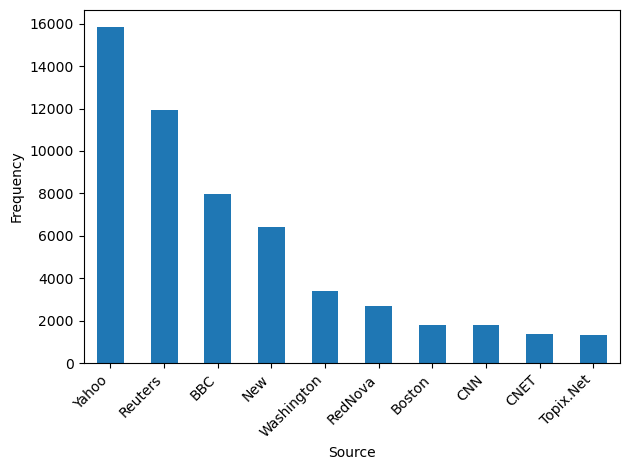

In [ ]:
source_nan = df["source"].isna().sum()
source_placeholder = (df["source"] == "\\N").sum()
source_empty = (df['source'].astype(str).str.strip() == '').sum()

print(f"Source NaN: {source_nan}")
print(f"Source Placeholders (\\N): {source_placeholder}")
print(f"Source Empty strings: {source_empty}")

sources = df["source"].replace("\\N", np.nan)
sources = sources.replace("", np.nan)
sources = sources.fillna("Other")

final_source_counts = sources.value_counts()
print(f"Number of sources: {len(final_source_counts)}")

top_sources = sources.value_counts().head(10)

plt.figure()
top_sources.plot(kind="bar")
plt.xlabel("Source")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig("plot/top_sources.pdf", bbox_inches="tight")
plt.show()

### *PageRank* Inspection

In [15]:
pr_nan = df['page_rank'].isna().sum()
pr_placeholder = (df['page_rank']=='\\N').sum()
pr_empty = (df['page_rank'].astype(str).str.strip()=='').sum()
rank_5=np.array([df['page_rank']==5]).sum()
rank_vals=np.unique(df['page_rank'])

print(f"PageRank NaN: {pr_nan}")
print(f"PageRank Placeholders (\\N): {pr_placeholder}")
print(f"PageRank Empty strings: {pr_empty}")
print(f"Number of articles with PageRank 5: {rank_5}")
print(f"Distinct PageRank: {rank_vals}")

PageRank NaN: 0
PageRank Placeholders (\N): 0
PageRank Empty strings: 0
Number of articles with PageRank 5: 73891
Distinct PageRank: [2 3 4 5]


### *Timestamp* Inspection

In [ ]:
time_nan = df['timestamp'].isna().sum()
time_placeholder = (df['timestamp']=='\\N').sum()
time_empty = (df['timestamp'].astype(str).str.strip()=='').sum()
time_useless=np.array([df['timestamp']=="0000-00-00 00:00:00"]).sum()

print(f"Timestamp NaN: {time_nan}")
print(f"Timestamp Placeholders (\\N): {time_placeholder}")
print(f"Timestamp Empty strings: {time_empty}")
print(f"Invalid dates (0000-00-00 00:00:00): {time_useless}")

Timestamp NaN: 0
Timestamp placeholders (\N): 0
Timestamp Empty strings: 0
Invalid dates (0000-00-00 00:00:00): 27750


### *Title* Inspection

In [16]:
title_nan = df['title'].isna().sum()
title_placeholder = (df['title']== '\\N').sum()
title_empty = (df['title'].astype(str).str.strip()=='').sum()

print(f"Title NaN: {title_nan}")
print(f"Title Placeholders (\\N): {title_placeholder}")
print(f"Title Empty rows: {title_empty}")
print("Title sample:")
print(df['title'].sample(5))

Title NaN: 1
Title Placeholders (\N): 0
Title Empty rows: 2
Title sample:
Id
191                        Amusement, amazement greet news
48807    Transatlantic flight turns back to London over...
54843    Texas counties illegally posting Social Securi...
42064              Nigerian militant agrees to cease raids
49213    Associated Press Football Poll Is Pulled From ...
Name: title, dtype: object


### *Article* Inspection

In [17]:
article_nan = df['article'].isna().sum()
article_placeholder = (df['article']=='\\N').sum()
article_empty = (df['article'].astype(str).str.strip()=='').sum()

print(f"Number of NaN rows: {article_nan}")
print(f"Number of placeholders (\\N): {article_placeholder}")
print(f"Number of empty rows: {article_empty}")
print("Article sample")
print(df['article'].sample(5))

Number of NaN rows: 1
Number of placeholders (\N): 1874
Number of empty rows: 7
Article sample
Id
10135    Although oil prices have remained at historica...
37994    <p><a href="http://us.rd.yahoo.com/dailynews/r...
7277     LOS ANGELES (Reuters) - Hollywood on Sunday aw...
29401    Sir, With reference to your reports headlined ...
38660     SANAA (Reuters) - Yemeni President Ali Abdull...
Name: article, dtype: object


### Feature Engineering

In [ ]:
def clean_title(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\.\,\-\%\$\€\£]", " ", text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_article(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = ftfy.fix_text(text)
    text = html.unescape(text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\b(a\s+href|href|img\s+src|nbsp|read\s+more|click\s+here)\b',' ', text, flags=re.IGNORECASE)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\.\,\-\%\$\€\£]", " ", text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_features(df):
    df = df.copy()

    df["source"] = (df["source"].replace(["\\N", ""], np.nan).fillna("Other").astype(str))

    dt = pd.to_datetime(df["timestamp"], errors="coerce")

    df["has_date"] = dt.notna().astype(int)
    df["quarter"] = dt.dt.quarter.fillna(-1).astype(int)
    df["is_weekend"] = dt.dt.dayofweek.isin([5, 6]).fillna(False).astype(int)

    title_clean = df["title"].replace("\\N", "").apply(clean_title)
    article_clean = df["article"].replace("\\N", "").apply(clean_article)

    df["text"] = (title_clean + " " + article_clean).str.strip()

    df = df[["text", "source", "page_rank", "has_date", "is_weekend", "quarter"]]

    return df

### Preprocessing and Model validation

In [ ]:
text_cols = "text"
cat_cols = ["source"]
num_cols = ["page_rank", "has_date", "is_weekend", "quarter"]

X = df.drop(columns=['label'])
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = Pipeline([
    ("vec", TfidfVectorizer(
        sublinear_tf=True,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.95,
        max_features=400_000,   
        lowercase=False
    )),
    ("chi2", SelectKBest(chi2, k=80_000))
])

preprocess = ColumnTransformer(
    transformers=[
        ("text", vectorizer, text_cols),
        ("source", OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            min_frequency=5,
            sparse_output=True
        ), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

pipeline = Pipeline([
    ("features", FunctionTransformer(build_features, validate=False)),
    ("prep", preprocess),
    ("clf", LinearSVC(class_weight="balanced", loss="squared_hinge", random_state=42)),
])

param_grid = {
    "prep__text__chi2__k": [60_000, 80_000, 100_000, 120_000],
    "clf__C": np.logspace(-3, 0.5, 10),  
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=12,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)
best_model = search.best_estimator_
y_val_pred = best_model.predict(X_val)

### Quality assessment

In [ ]:
print("Best parameters:", search.best_params_)
print("Validation Macro F1:", f1_score(y_val, y_val_pred, average="macro"))
print(classification_report(y_val, y_val_pred, digits=4))

### Final submission

In [ ]:
best_model.fit(X, y) 
pred_eval = best_model.predict(df_eval)

submission_df = pd.DataFrame({
    "Id": df_eval.index,
    "Predicted": pred_eval
})

submission_df.to_csv("submission.csv", index=False)
print(submission_df.head())